In [1]:
import json

items = []
t = 0

with open("CraiglistBargaintrain.json", "r") as f:
    data = json.load(f)

data[0]["scenario"]

{'category': 'phone',
 'uuid': 'S_6Bcls3VtniHs9vXk',
 'post_id': '6149527852',
 'kbs': [{'personal': {'Bottomline': None, 'Role': 'buyer', 'Target': 7},
   'item': {'Category': 'phone',
    'Images': ['phone/6149527852_0.jpg'],
    'Price': 10,
    'Description': ['Charge two devices simultaneously on the go. This vehicle charger with an additional USB port delivers enough power to charge two devices at once. The push-button activated LED connector light means no more fumbling in the dark trying to connect your device. Auto Detect IC Technology automatically detects the device type and its specific charging needs for improved compatibility. And the built-in indicator light illuminates red to let you know the charger is receiving power and the power socket is working properly.'],
    'Title': 'Verizon Car Charger with Dual Output Micro USB and LED Light'}},
  {'personal': {'Bottomline': None, 'Role': 'seller', 'Target': 10},
   'item': {'Category': 'phone',
    'Images': ['phone/6149527

In [2]:
data[0]["scenario"]["kbs"][0]

{'personal': {'Bottomline': None, 'Role': 'buyer', 'Target': 7},
 'item': {'Category': 'phone',
  'Images': ['phone/6149527852_0.jpg'],
  'Price': 10,
  'Description': ['Charge two devices simultaneously on the go. This vehicle charger with an additional USB port delivers enough power to charge two devices at once. The push-button activated LED connector light means no more fumbling in the dark trying to connect your device. Auto Detect IC Technology automatically detects the device type and its specific charging needs for improved compatibility. And the built-in indicator light illuminates red to let you know the charger is receiving power and the power socket is working properly.'],
  'Title': 'Verizon Car Charger with Dual Output Micro USB and LED Light'}}

In [3]:
data[0]["scenario"]["kbs"][1]

{'personal': {'Bottomline': None, 'Role': 'seller', 'Target': 10},
 'item': {'Category': 'phone',
  'Images': ['phone/6149527852_0.jpg'],
  'Price': 10,
  'Description': ['Charge two devices simultaneously on the go. This vehicle charger with an additional USB port delivers enough power to charge two devices at once. The push-button activated LED connector light means no more fumbling in the dark trying to connect your device. Auto Detect IC Technology automatically detects the device type and its specific charging needs for improved compatibility. And the built-in indicator light illuminates red to let you know the charger is receiving power and the power socket is working properly.'],
  'Title': 'Verizon Car Charger with Dual Output Micro USB and LED Light'}}

In [8]:
import json
import pandas as pd
import numpy as np

# Load dataset
with open("CraiglistBargaintrain.json", "r") as f:
    data = json.load(f)

rows = []
idx = 0

for entry in data:
    scenario = entry.get("scenario", {})
    kbs = scenario.get("kbs", [])

    if len(kbs) != 2:
        continue  # Skip malformed entries

    # Identify buyer and seller KBs safely
    buyer_kb = next((kb for kb in kbs if kb["personal"]["Role"] == "buyer"), None)
    seller_kb = next((kb for kb in kbs if kb["personal"]["Role"] == "seller"), None)

    if not buyer_kb or not seller_kb:
        continue

    item = seller_kb.get("item", {})

    gap = seller_kb["personal"].get("Target") - buyer_kb["personal"].get("Target")
    u = np.random.uniform(low=0, high=0.3)
    
    rows.append({
        # IDs
        "id": idx,
        "scenario_id": scenario.get("uuid"),

        # Item information
        "category": item.get("Category"),
        "title": item.get("Title"),
        "description": " ".join(item.get("Description", [])),
        "listing_price": item.get("Price"),

        # Buyer info
        "buyer_target": buyer_kb["personal"].get("Target"),
        "buyer_cost": seller_kb["personal"].get("Target"), # buyer cost = listing price

        # Seller info
        "seller_target": seller_kb["personal"].get("Target"),
        "seller_cost": buyer_kb["personal"].get("Target") - int(u * gap) # seller cost = little under buyer target
    })

    idx += 1

# Convert to DataFrame
df = pd.DataFrame(rows)

# Optional: drop exact duplicates (same scenario_id)
df = df.drop_duplicates(subset=["scenario_id"])

# Save to CSV
df.to_csv("craigslist_bargain_scenarios_new.csv", index=False)

print("CSV created: craigslist_bargain_scenarios.csv")
print("Total scenarios extracted:", len(df))

CSV created: craigslist_bargain_scenarios.csv
Total scenarios extracted: 3304


In [9]:
df.head()

,id,scenario_id,category,title,description,listing_price,buyer_target,buyer_cost,seller_target,seller_cost
0,0,S_6Bcls3VtniHs9vXk,phone,Verizon Car Charger with Dual Output Micro USB...,Charge two devices simultaneously on the go. T...,10,7,10,10,7
1,1,S_KBCT5vA6znuh9TvV,bike,Long board custom bilt from the board up,Hey there cl I have a long board for sale pret...,200,120,200,200,119
2,2,S_Jrg93XX4AYzY9IQ7,housing,A 4 bedroom single family house for rent in ce...,This is a single family house in an excellent ...,3200,1920,3200,3200,1878
3,3,S_BPTzvYVeri3mn93K,furniture,Sectional Couch,I am remodeling my space and selling a beautif...,585,444,585,585,408
4,4,S_d4C8thhPACvbiI0Q,furniture,Beautiful Cherry Hutch,MUST SEE!!! Like new ! - making space in our D...,1000,600,1000,1000,499


In [10]:
df[df["id"] == 0]

,id,scenario_id,category,title,description,listing_price,buyer_target,buyer_cost,seller_target,seller_cost
0,0,S_6Bcls3VtniHs9vXk,phone,Verizon Car Charger with Dual Output Micro USB...,Charge two devices simultaneously on the go. T...,10,7,10,10,7


In [13]:
df = pd.read_csv("bargain_langgraph/craiglist/data/craigslist_bargain_scenarios_new.csv")

row = df[df["id"] == 0].iloc[0]
row

id                                                               0
scenario_id                                     S_6Bcls3VtniHs9vXk
category                                                     phone
title            Verizon Car Charger with Dual Output Micro USB...
description      Charge two devices simultaneously on the go. T...
listing_price                                                   10
buyer_target                                                     7
buyer_cost                                                      10
seller_target                                                   10
seller_cost                                                      7
Name: 0, dtype: object

In [16]:
df[["id", "category", "buyer_cost", "seller_cost", "buyer_target", "seller_target"]].head(10)

,id,category,buyer_cost,seller_cost,buyer_target,seller_target
0,0,phone,10,7,7,10
1,1,bike,200,119,120,200
2,2,housing,3200,1878,1920,3200
3,3,furniture,585,408,444,585
4,4,furniture,1000,499,600,1000
5,5,furniture,18,10,10,18
6,6,car,14500,8264,8700,14500
7,7,housing,1895,1711,1743,1895
8,8,car,8800,6377,6688,8800
9,9,car,26800,24440,24656,26800


# Craiglist Simulation Results

In [4]:
import pandas as pd
import numpy as np
import json
import pandas as pd
import numpy as np

df = pd.read_csv("simulation_results_craiglist/results.csv")
df.head()

,id,product_name,buyer_cost,seller_cost,buyer_target,seller_target,buyer_emotion,seller_emotion,success,turns,savings,reward
0,0,Verizon Car Charger with Dual Output Micro USB...,10,7,7,10,anger,anger,True,5,0.600000,0.229935
1,0,Verizon Car Charger with Dual Output Micro USB...,10,7,7,10,anger,disgust,True,6,0.616667,0.220888
2,0,Verizon Car Charger with Dual Output Micro USB...,10,7,7,10,anger,fear,True,5,0.700000,0.268257
3,0,Verizon Car Charger with Dual Output Micro USB...,10,7,7,10,anger,happy,True,6,0.683333,0.244768
4,0,Verizon Car Charger with Dual Output Micro USB...,10,7,7,10,anger,sad,True,5,0.633333,0.242709


In [5]:
metric_names = ["success", "turns", "savings", "reward"]

df[df["success"] == False]

,id,product_name,buyer_cost,seller_cost,buyer_target,seller_target,buyer_emotion,seller_emotion,success,turns,savings,reward
328,6,2006 Toyota 4Runner 4WD - Only 106k Miles - Cl...,14500,8264,8700,14500,sad,neutral,False,10,0.0,0.0
333,6,2006 Toyota 4Runner 4WD - Only 106k Miles - Cl...,14500,8264,8700,14500,surprise,sad,False,10,0.0,0.0


In [17]:
def get_conversation(id, buyer_emotion, seller_emotion):
    with open("simulation_results_craiglist/histories.jsonl", "r") as f:
        for line in f:
            record = json.loads(line)

            if (
                record["id"] == id
                and record["buyer_emotion"] == buyer_emotion
                and record["seller_emotion"] == seller_emotion
            ):
                history = record["final_state"]["history"]
                for item in history:
                    print(f"{item['role']}: {item['message']} \n")
    return None

In [18]:
get_conversation(id=6, buyer_emotion="sad", seller_emotion="neutral")

seller: Hi, I am selling a 2006 Toyota 4Runner 4WD - Only 106k Miles - Clean Title for $14500. Are you interested? 

buyer: I really like the truck, but $14,500 is quite a bit over my budget. I can offer $8,000, which I hope is fair given the age and condition. I’m feeling a bit down about this, but I’d love to make it work. 

seller: I understand your budget concerns and really want to make this work for you. I can decrease my offer to $13,500, which is a fair price given the truck's condition and mileage. Let me know if this works for you. 

buyer: I really want to make this work, but $13,500 is still quite far from what I can manage. I can increase my offer to $8,800, which is close to my budget and still fair considering the truck’s age. I hope we can find a middle ground. 

seller: I appreciate your willingness to increase your offer. I can decrease my offer to $12,500, which is a fair middle ground considering the truck’s excellent condition and mileage. Let me know if this works

In [8]:
b = "neutral"
e = "happy"
df[(df["buyer_emotion"] == b) & (df["seller_emotion"] == e)]

,id,product_name,buyer_cost,seller_cost,buyer_target,seller_target,buyer_emotion,seller_emotion,success,turns,savings,reward
45,0,Verizon Car Charger with Dual Output Micro USB...,10,7,7,10,neutral,happy,True,5,0.600000,0.229935
94,1,Long board custom bilt from the board up,200,119,120,200,neutral,happy,True,6,0.469136,0.168043
143,2,A 4 bedroom single family house for rent in ce...,3200,1878,1920,3200,neutral,happy,True,7,0.404690,0.137373
192,3,Sectional Couch,585,408,444,585,neutral,happy,True,7,0.525424,0.178357
241,4,Beautiful Cherry Hutch,1000,499,600,1000,neutral,happy,True,8,0.469062,0.152320
290,5,Office Client Waiting Room CHAIRS,18,10,10,18,neutral,happy,True,5,0.387500,0.148499
339,6,2006 Toyota 4Runner 4WD - Only 106k Miles - Cl...,14500,8264,8700,14500,neutral,happy,True,9,0.493105,0.154229
388,7,Beautiful Renovated Studio with Balcony by Lak...,1895,1711,1743,1895,neutral,happy,True,5,0.625000,0.239515
437,8,2007 Mazda cx-9,8800,6377,6688,8800,neutral,happy,True,8,0.550970,0.178919
486,9,2016 mercedes benz c300,26800,24440,24656,26800,neutral,happy,True,6,0.508475,0.182134


In [9]:
import matplotlib.pyplot as plt

def summarize(metric="reward"):
    emotions = [
        "anger",
        "disgust",
        "fear",
        "happy",
        "sad",
        "surprise",
        "neutral"
    ]

    matrix = np.zeros((len(emotions), len(emotions)))
    for i, b in enumerate(emotions):
        for j, s in enumerate(emotions):
            df_ = df[(df["buyer_emotion"] == b) & (df["seller_emotion"] == s)]
            matrix[i, j] = np.mean(df_[metric])

    return matrix

def plot_emotion_matrix(metric="reward"):
    emotions = [
        "anger",
        "disgust",
        "fear",
        "happy",
        "sad",
        "surprise",
        "neutral"
    ]

    matrix = summarize(metric)

    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(matrix)

    # ticks
    ax.set_xticks(np.arange(len(emotions)))
    ax.set_yticks(np.arange(len(emotions)))

    ax.set_xticklabels(emotions)
    ax.set_yticklabels(emotions)

    # axis labels
    ax.set_xlabel("Seller Emotion")
    ax.set_ylabel("Buyer Emotion")
    ax.set_title(f"Average {metric} by Emotion Pair")

    # rotate seller labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # annotate cells
    for i in range(len(emotions)):
        for j in range(len(emotions)):
            ax.text(j, i, f"{matrix[i, j]:.2f}",
                    ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

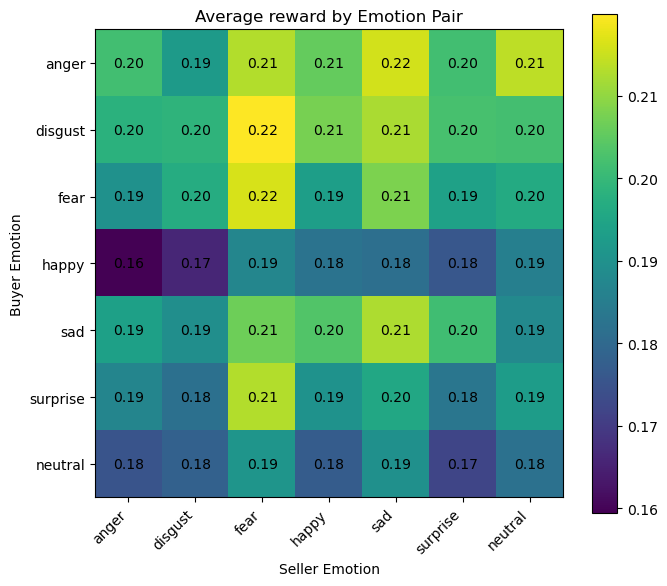

In [10]:
plot_emotion_matrix("reward")

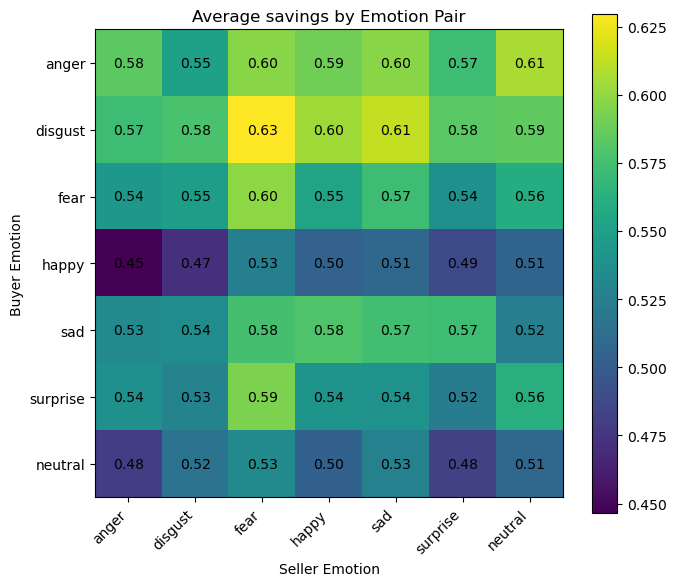

In [11]:
plot_emotion_matrix("savings")

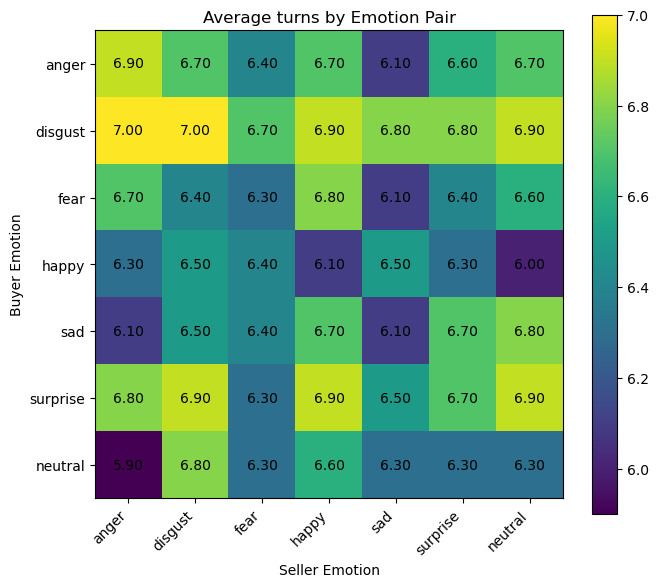

In [12]:
plot_emotion_matrix("turns")

In [21]:
get_conversation(id=6, buyer_emotion="anger", seller_emotion="disgust")

seller: Hi, I am selling a 2006 Toyota 4Runner 4WD - Only 106k Miles - Clean Title for $14500. Are you interested? 

buyer: Look, $14,500 is way off the mark for a 2006 model with scratches and wear. I’m willing to pay $8,700, which is fair given the age and condition. Take it or leave it. 

seller: I find your offer quite insulting given the condition and care this 4Runner has received. I can decrease my offer to $13,500, which is already a significant concession. Take it seriously or move on. 

buyer: Look, I get that you care about the truck, but $13,500 is way too high. I can increase my offer to $9,300, which is more than fair for a 2006 model with visible wear. Take it seriously or we’re done here. 

seller: I can decrease my offer to $12,800, but $9,300 is just not close to the value of this well-maintained 4Runner. If you want a reliable truck that’s been cared for, this is a fair price. 

buyer: I can increase my offer to $9,900, but $12,800 is still way out of line for this t

In [26]:
get_conversation(id=5, buyer_emotion="surprise", seller_emotion="surprise")

seller: Hi, I am selling a Office Client Waiting Room CHAIRS for $18. Are you interested? 

buyer: Wow, $18 seems quite high for chairs with some wear and tear. I can offer $12, which I think is fair given their condition. Would you consider that? 

seller: Wow, I’m a bit surprised by your low offer given the chairs are still sturdy and good for use. I can decrease my offer to $16.50, which I think is a fair middle ground considering their condition. Would you be willing to meet me there? 

buyer: I’m quite surprised by the jump from $12 to $16.50, but I can increase my offer to $13.50 as a sign of good faith. I hope we can find a middle ground that respects the chairs’ condition. 

seller: I’m quite surprised too, but I appreciate your good faith offer. I can decrease my offer to $15.50 as a fair middle ground considering the chairs’ sturdy condition. Let’s try to find a deal that works for both of us. 

buyer: I’m quite surprised by the jump to $15.50, but I can increase my offer to 

In [27]:
get_conversation(id=5, buyer_emotion="surprise", seller_emotion="neutral")

seller: Hi, I am selling a Office Client Waiting Room CHAIRS for $18. Are you interested? 

buyer: Wow, $18 seems quite high for chairs with some wear and tear. I can offer $12 considering their condition—would you be willing to negotiate around that? 

seller: I understand your concern about the wear and tear. I can decrease my offer to $16.50, which I believe is fair given the chairs' sturdiness and usefulness for a waiting room. 

buyer: I’m honestly surprised by how high $16.50 still is given the wear and tear. I can increase my offer to $13.50, which I think is a fair middle ground considering the condition. 

seller: I understand your point about the wear and tear, so I can decrease my offer to $15.50. This price still reflects the chairs' sturdiness and usefulness for your waiting room. Let me know if this works for you. 

buyer: I’m honestly surprised that $15.50 is still the best you can do given the wear and tear. I can increase my offer to $14.50 as a fair compromise. Can we

In [28]:
get_conversation(id=5, buyer_emotion="anger", seller_emotion="neutral")

seller: Hi, I am selling a Office Client Waiting Room CHAIRS for $18. Are you interested? 

buyer: Honestly, $18 is way too high for chairs with tears and wear. I can offer $11, which is already generous given their condition. Take it or leave it. 

seller: I understand your concern about the condition. I can decrease my offer to $16.50, which is a fair price for sturdy chairs that still serve well in a waiting room. Would you consider this? 

buyer: Look, $16.50 is still way too high for chairs with visible tears. I can increase my offer to $12.50, which is more than fair given their condition. Take it or leave it. 

seller: I understand the concern about the tears, so I can decrease my offer to $15. These chairs are still sturdy and great for a waiting room, making this a fair price. Would you consider this compromise? 

buyer: I get that you think $15 is fair, but these tears seriously lower the value. I can increase my offer to $13.50, which is already pushing it given the conditio